# Spherical Fourier Neural Operators

A simple notebook to showcase spherical Fourier Neural Operators


## Preparation

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.cuda import amp
from torch.optim.lr_scheduler import OneCycleLR

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from math import ceil, sqrt

import time
import wandb

cmap='twilight_shifted'

In [17]:
enable_amp = False

# set device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.set_device(device.index)

device

device(type='cuda', index=0)

### Training data
to train our geometric FNOs, we require training data. To this end let us prepare a Dataloader which computes results on the fly:

In [3]:
# dataset
from torch_harmonics.examples import PdeDataset
from torch_harmonics.examples.models import SphericalFourierNeuralOperator, LocalSphericalNeuralOperator, SphericalTransformer

# 1 hour prediction steps
dt = 1*1800
dt_solver = 100
nsteps = dt//dt_solver
grid = "equiangular"
dataset = PdeDataset(dt=dt, nsteps=nsteps, dims=(241, 480), device=device, normalize=True, grid=grid)
# There is still an issue with parallel dataloading. Do NOT use it at the moment
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0, persistent_workers=False)
solver = dataset.solver.to(device)

nlat = dataset.nlat
nlon = dataset.nlon

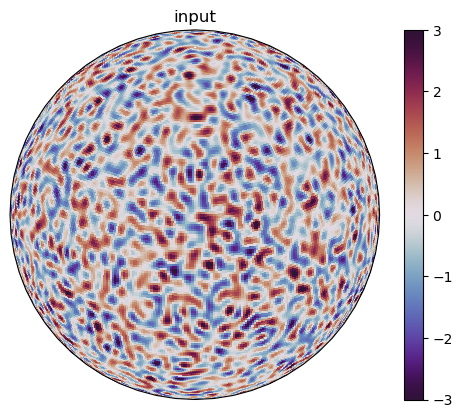

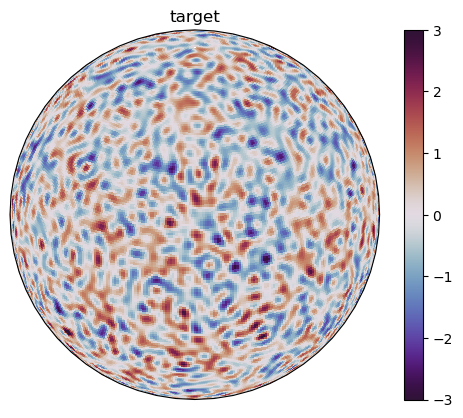

In [14]:
torch.manual_seed(0)
inp, tar = dataset[0]

fig = plt.figure()
im = solver.plot_griddata(inp[0], fig, vmax=3, vmin=-3)
plt.title("input")
plt.colorbar(im)
plt.show()

fig = plt.figure()
im = solver.plot_griddata(tar[0], fig, vmax=3, vmin=-3)
plt.title("target")
plt.colorbar(im)
plt.show()

### Defining the Spherical Neural Operator

In [4]:
model = SphericalFourierNeuralOperator(img_size=(nlat, nlon), grid=grid, num_layers=4, scale_factor=1, embed_dim=16, residual_prediction=True, pos_embed="spectral", use_mlp=True, normalization_layer="none").to(device)

## Training the model
next step to try: mix of l2+spectral l2 loss for error

In [5]:
def l2loss_sphere(solver, prd, tar, relative=False, squared=True):
    loss = solver.integrate_grid((prd - tar)**2, dimensionless=True).sum(dim=-1)
    if relative:
        loss = loss / solver.integrate_grid(tar**2, dimensionless=True).sum(dim=-1)

    if not squared:
        loss = torch.sqrt(loss)
    loss = loss.mean()

    return loss

def spectral_l2loss_sphere(solver, prd, tar, relative=False, squared=True):
    # compute coefficients
    coeffs = torch.view_as_real(solver.sht(prd - tar))
    coeffs = coeffs[..., 0]**2 + coeffs[..., 1]**2
    norm2 = coeffs[..., :, 0] + 2 * torch.sum(coeffs[..., :, 1:], dim=-1)
    loss = torch.sum(norm2, dim=(-1,-2))

    if relative:
        tar_coeffs = torch.view_as_real(solver.sht(tar))
        tar_coeffs = tar_coeffs[..., 0]**2 + tar_coeffs[..., 1]**2
        tar_norm2 = tar_coeffs[..., :, 0] + 2 * torch.sum(tar_coeffs[..., :, 1:], dim=-1)
        tar_norm2 = torch.sum(tar_norm2, dim=(-1,-2))
        loss = loss / tar_norm2

    if not squared:
        loss = torch.sqrt(loss)
    loss = loss.mean()

    return loss

In [11]:
# set seed
torch.manual_seed(333)
torch.cuda.manual_seed(333)

config = {
    'neopchs':40,
    'project':'cs598-sfno',
    'loss_fn':'l2',
    'lr':3e-2,#3E-3,
    'n_steps':20, #autoregressive timestep
    'n_future':0
    'num_examples':256,
    'num_valid':8
}

optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=0.0)
gscaler = amp.GradScaler(enabled=enable_amp)
train_model(model, dataloader, optimizer, nepochs=config['neopchs'],loss_fn=config['loss_fn'],nfuture=1)

# multistep training
# learning_rate = 5e-4
# optimizer = torch.optim.Adam(fno_model.parameters(), lr=learning_rate)
# dataloader.dataset.nsteps = 2 * dt//dt_solver
# train_model(fno_model, dataloader, optimizer, nepochs=10, nfuture=1)
# dataloader.dataset.nsteps = 1 * dt//dt_solver

In [18]:
# training loop 
acc_losshistory = []
valid_losshistory = []
scheduler=None


train_start = time.time()
with wandb.init(project=config["project"], config=config) as run:
    for epoch in range(config['neopchs']):

        # time each epoch
        epoch_start = time.time()

        dataloader.dataset.set_initial_condition('random')
        dataloader.dataset.set_num_examples(config['num_examples'])

        optimizer.zero_grad(set_to_none=True)

        # do the training
        acc_loss = 0
        model.train()
        for inp, tar in dataloader:
            with amp.autocast(enabled=enable_amp):
                # print(inp.shape)
                prd = model(inp)
                for _ in range(config['n_future']):
                    prd = model(prd)
                if config['loss_fn'] == 'l2':
                    loss = l2loss_sphere(solver, prd, tar, relative=True)
                elif config['loss_fn'] == "spectral l2":
                    loss = spectral_l2loss_sphere(solver, prd, tar, relative=True)

            acc_loss += loss.item() * inp.size(0)

            optimizer.zero_grad(set_to_none=True)
            # gscaler.scale(loss).backward()
            loss.backward()
            optimizer.step()
            # gscaler.update()

        if scheduler is not None:
            scheduler.step()

        acc_loss = acc_loss / len(dataloader.dataset)
        acc_losshistory.append(acc_loss)

        dataloader.dataset.set_initial_condition('random')
        dataloader.dataset.set_num_examples(config['num_valid'])

        # perform validation
        valid_loss = 0
        model.eval()
        with torch.no_grad():
            for inp, tar in dataloader:
                prd = model(inp)
                for _ in range(config['n_future']):
                    prd = model(prd)
                loss = l2loss_sphere(solver, prd, tar, relative=True)

                valid_loss += loss.item() * inp.size(0)

        valid_loss = valid_loss / len(dataloader.dataset)
        valid_losshistory.append(valid_loss)

        epoch_time = time.time() - epoch_start

        print(f'--------------------------------------------------------------------------------')
        print(f'Epoch {epoch} summary:')
        print(f'time taken: {epoch_time}')
        print(f'accumulated training loss: {acc_loss}')
        print(f'relative validation loss: {valid_loss}')

train_time = time.time() - train_start

print(f'--------------------------------------------------------------------------------')
print(f'done. Training took {train_time}.')

IndentationError: unexpected indent (3968677630.py, line 7)

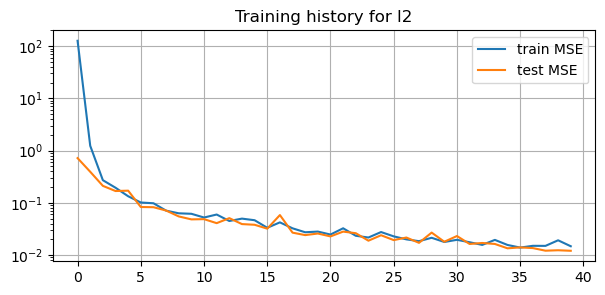

0.014727777495863847 0.012057940475642681


In [15]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(config['neopchs']),acc_losshistory[-40:], label='train MSE')
ax.plot(range(config['neopchs']),valid_losshistory[-40:], label='test MSE')
ax.set_yscale('log')
ax.set_title('Training history for '+config['loss_fn'])
ax.grid()
ax.legend()
plt.show()
print(acc_losshistory[-1],valid_losshistory[-1])

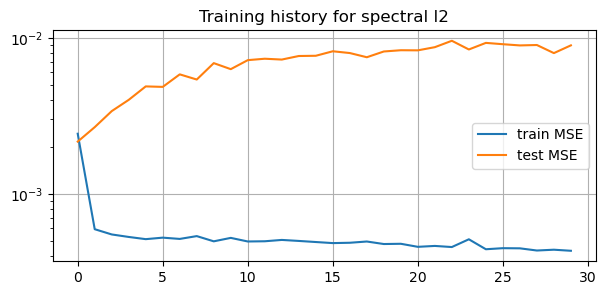

0.0004299160186747031 0.008956040255725384


In [43]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(config['neopchs']),acc_losshistory, label='train MSE')
ax.plot(range(config['neopchs']),valid_losshistory, label='test MSE')
ax.set_yscale('log')
ax.set_title('Training history for '+config['loss_fn'])
ax.grid()
ax.legend()
plt.show()
print(acc_losshistory[-1],valid_losshistory[-1])


In [ ]:
# weighted_spectral_l2
diff = f_pred - f_target  # [batch, modes_x, modes_y]
# You want a weight tensor W of shape [modes_x, modes_y]
# where W[0,0] is large, and it decays for higher frequencies
loss = torch.mean(W * diff.abs()**2)


In [30]:
import inspect
print(inspect.getsource(solver.timestep))

    def timestep(self, uspec: torch.Tensor, nsteps: int) -> torch.Tensor:
        """Integrate the solution using Adams-Bashforth / forward Euler for nsteps steps."""
        dudtspec = torch.zeros(3, 3, self.lmax, self.mmax, dtype=uspec.dtype, device=uspec.device)

        # pointers to indicate the most current result
        inew = 0
        inow = 1
        iold = 2

        for iter in range(nsteps):
            dudtspec[inew] = self.dudtspec(uspec)

            # update vort,div,phiv with third-order adams-bashforth.
            # forward euler, then 2nd-order adams-bashforth time steps to start.
            if iter == 0:
                dudtspec[inow] = dudtspec[inew]
                dudtspec[iold] = dudtspec[inew]
            elif iter == 1:
                dudtspec[iold] = dudtspec[inew]

            uspec = uspec + self.dt*( (23./12.) * dudtspec[inew] - (16./12.) * dudtspec[inow] + (5./12.) * dudtspec[iold] )

            # implicit hyperdiffusion for vort and div.
          

In [9]:
spec = solver.grid2spec(inp[0])  # remove batch dim, shape [3, 81, 81]
print(solver.timestep(spec, 1).shape)

NameError: name 'inp' is not defined

In [ ]:
with torch.inference_mode():
    inp, tar = next(iter(dataloader))
    inp = inp[0:1]  # [1, 3, 241, 480]

    n_rollout = 12

    # ground truth — solver needs no batch dim
    current_spec = solver.grid2spec(inp[0])  # [3, 81, 81]
    truths = [inp]
    for i in range(n_rollout):
        current_spec = solver.timestep(current_spec, nsteps)
        truth_grid = solver.spec2grid(current_spec).unsqueeze(0)  # add batch dim back [1, 3, 241, 480]
        truths.append(truth_grid)

    # model predictions — keeps batch dim
    predictions = [inp]
    current_pred = inp
    errors = []
    for i in range(n_rollout):
        current_pred = model(current_pred).detach()
        predictions.append(current_pred)
        error = torch.norm(current_pred - truths[i + 1]) / torch.norm(truths[i + 1])
        errors.append(error.item())

In [39]:
errors

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

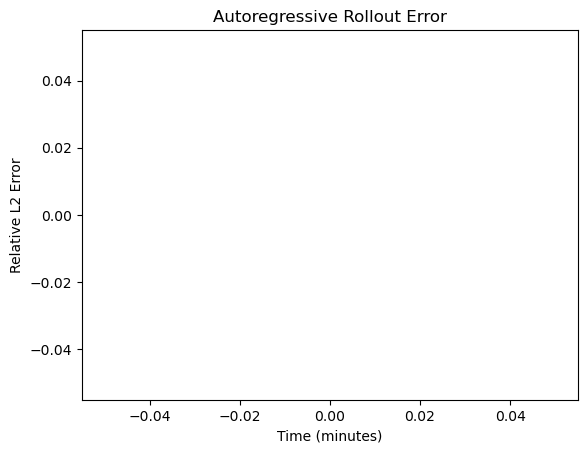

In [38]:
plt.plot([i * 30 for i in range(1, n_rollout + 1)], errors)
plt.xlabel('Time (minutes)')
plt.ylabel('Relative L2 Error')
plt.title('Autoregressive Rollout Error')
plt.show()

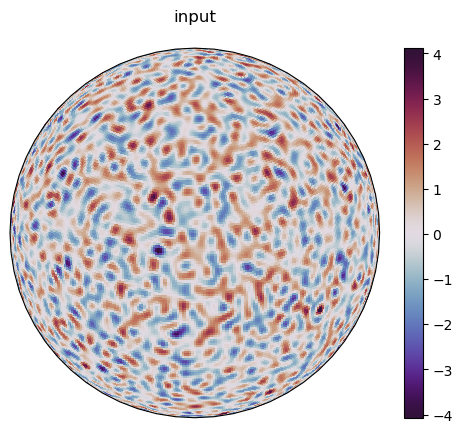

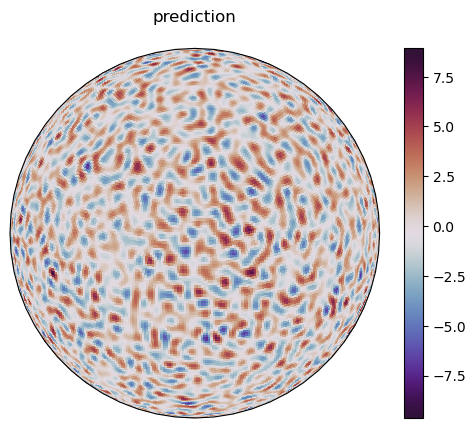

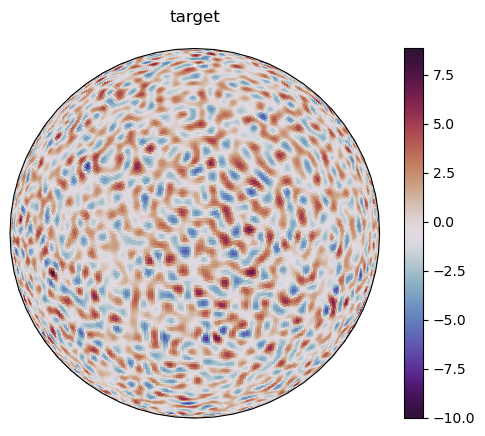

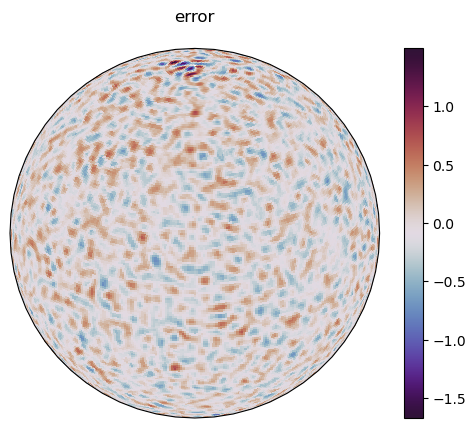

In [16]:
dataloader.dataset.set_initial_condition('random')

torch.manual_seed(0)

with torch.inference_mode():
    inp, tar = next(iter(dataloader))
    out = model(inp).detach()

s = 0; ch = 2

fig = plt.figure()
im = solver.plot_griddata(inp[s, ch], fig, projection='3d', title='input')
plt.colorbar(im)
plt.show()

fig = plt.figure()
im = solver.plot_griddata(out[s, ch], fig, projection='3d', title='prediction')
plt.colorbar(im)
plt.show()

fig = plt.figure()
im = solver.plot_griddata(tar[s, ch], fig, projection='3d', title='target')
plt.colorbar(im)
plt.show()

fig = plt.figure()
im = solver.plot_griddata((tar-out)[s, ch], fig, projection='3d', title='error')
plt.colorbar(im)
plt.show()

#### Animation (In-progress)

In [12]:
import matplotlib.pyplot as plt
from torch_harmonics.plotting import plot_sphere

In [10]:
import matplotlib.animation as animation

fig = plt.figure(layout='constrained', figsize=(12, 8), dpi=72)
subfigs = fig.subfigures(2, 2)

moviewriter = animation.writers['pillow'](fps=30)
moviewriter.setup(fig, 'sfno_inf.gif', dpi=72)

<Figure size 864x576 with 0 Axes>

In [18]:
row = 2 
col = 2 
vdm = [inp.cpu(),out.cpu(),tar,tar-out]
titles=['input','output','target','error']
for frame in range(120):
    # compute the rotation of the sphere
    lon = -120 - 3 * frame
    if frame % 10 == 0:
        print(f"frame={frame}")

    for i in range(row):
        for j in range(col):
            plot_sphere(vdm[col*i+j], fig=subfigs[i,j], projection="orthographic", title=titles[col*i+j], central_longitude=lon)

    plt.draw()
    moviewriter.grab_frame()

moviewriter.finish()

frame=0


TypeError: Dimensions of C (4, 3, 241, 480) should be one smaller than X(480) and Y(241) while using shading='flat' see help(pcolormesh)